# Aesha's Contribution

### Imports and Setup

In [1]:
%pip install opencv-python==4.7.0.72

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install torch-fidelity

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Define Transform & Load Dataset

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

# Normalize to [-1, 1] for DDPM
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.CenterCrop(32),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset_path = "../balanced_labeled_photos"
full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

# Use only a small subset for fast testing
subset_indices = np.random.choice(len(full_dataset), size=1000, replace=False)
dataset = Subset(full_dataset, subset_indices)

dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

# Class mapping
print("Classes:", full_dataset.classes)
num_classes = len(full_dataset.classes)


Classes: ['balanced_labeled_photos']


### Quick Image Grid

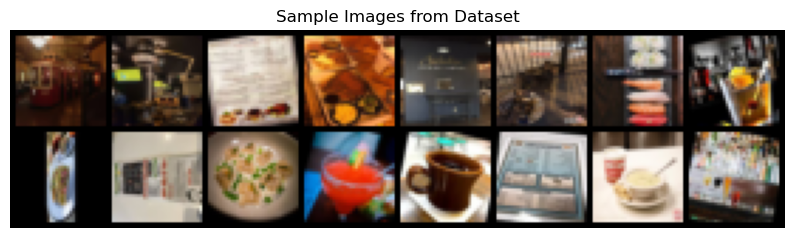

In [5]:
images, labels = next(iter(dataloader))
images = images[:16] * 0.5 + 0.5  # De-normalize

plt.figure(figsize=(10, 5))
plt.axis("off")
plt.title("Sample Images from Dataset")
plt.imshow(vutils.make_grid(images, nrow=8).permute(1, 2, 0))
plt.show()


## Define the Improved Conditional UNet for DDPM

### Timestep Embedding

In [6]:
import torch.nn as nn
import torch.nn.functional as F

def get_timestep_embedding(timesteps, dim):
    half_dim = dim // 2
    emb = torch.exp(torch.arange(half_dim, device=timesteps.device) * -(torch.log(torch.tensor(10000.0)) / (half_dim - 1)))
    emb = timesteps[:, None] * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    return emb  # shape: [B, dim]


### Residual Block (with timestep and label conditioning)

In [7]:
class ConditionalResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        self.time_emb_proj = nn.Linear(emb_dim, out_ch)
        self.label_emb_proj = nn.Linear(emb_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.BatchNorm2d(out_ch)
        self.norm2 = nn.BatchNorm2d(out_ch)
        self.act = nn.SiLU()

        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb, y_emb):
        h = self.act(self.norm1(self.conv1(x)))
        h += self.time_emb_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h += self.label_emb_proj(y_emb).unsqueeze(-1).unsqueeze(-1)
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.skip(x)


### Full Conditional UNet

In [8]:
class ConditionalUNet(nn.Module):
    def __init__(self, num_classes, img_channels=3, base_channels=64, time_emb_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )
        self.label_emb = nn.Embedding(num_classes, time_emb_dim)

        self.enc1 = ConditionalResBlock(img_channels, base_channels, time_emb_dim)
        self.enc2 = ConditionalResBlock(base_channels, base_channels*2, time_emb_dim)
        self.enc3 = ConditionalResBlock(base_channels*2, base_channels*4, time_emb_dim)

        self.mid = ConditionalResBlock(base_channels*4, base_channels*4, time_emb_dim)

        self.dec3 = ConditionalResBlock(base_channels*4, base_channels*2, time_emb_dim)
        self.dec2 = ConditionalResBlock(base_channels*2, base_channels, time_emb_dim)
        self.dec1 = ConditionalResBlock(base_channels, img_channels, time_emb_dim)

        self.down = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x, t, y):
        t_emb = self.time_mlp(get_timestep_embedding(t, self.time_mlp[0].in_features))
        y_emb = self.label_emb(y)

        x1 = self.enc1(x, t_emb, y_emb)
        x2 = self.enc2(self.down(x1), t_emb, y_emb)
        x3 = self.enc3(self.down(x2), t_emb, y_emb)

        x_mid = self.mid(self.down(x3), t_emb, y_emb)

        x = self.up(x_mid)
        x = self.dec3(x + x3, t_emb, y_emb)
        x = self.up(x)
        x = self.dec2(x + x2, t_emb, y_emb)
        x = self.up(x)
        x = self.dec1(x + x1, t_emb, y_emb)

        return x


### Instantiate Model

In [9]:
model = ConditionalUNet(num_classes=num_classes).to(device)
print("Model initialized on", device)

Model initialized on cpu


## Forward Diffusion Process

### Noise Schedule Setup

In [10]:
import numpy as np

# Total diffusion steps
T = 300  # You can tune this later (500, 1000...)

# Linear beta schedule
betas = torch.linspace(1e-4, 0.02, T).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)


### Forward Diffusion Function

In [11]:
def forward_diffusion_sample(x_0, t):
    """
    Adds noise to x_0 at timestep t.
    Returns x_t and the actual noise.
    """
    noise = torch.randn_like(x_0)
    sqrt_acp_t = sqrt_alphas_cumprod[t][:, None, None, None]
    sqrt_om_acp_t = sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
    x_t = sqrt_acp_t * x_0 + sqrt_om_acp_t * noise
    return x_t, noise


### Visualize Noisy Images Over Time

In [12]:
def show_noisy_samples():
    x, _ = next(iter(dataloader))
    x = x.to(device)[:8]
    steps = [0, 50, 100, 200, 299]
    fig, axes = plt.subplots(1, len(steps), figsize=(15, 3))
    for i, step in enumerate(steps):
        t = torch.full((x.size(0),), step, device=device, dtype=torch.long)
        noisy_x, _ = forward_diffusion_sample(x, t)
        noisy_x = (noisy_x * 0.5 + 0.5).clamp(0, 1)  # de-normalize
        grid = vutils.make_grid(noisy_x, nrow=4)
        axes[i].imshow(grid.permute(1, 2, 0).cpu())
        axes[i].set_title(f"t={step}")
        axes[i].axis("off")
    plt.show()



## Training Loop

### Define Loss & Optimizer

In [13]:
import torch.nn as nn
import torch.optim as optim

# Mean squared error loss
loss_fn = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)


### Training Loop

In [14]:
from tqdm import tqdm

epochs = 100

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for batch in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
        x_0, y = batch
        x_0 = x_0.to(device)
        y = y.to(device)

        # Sample random timestep for each sample in batch
        t = torch.randint(0, T, (x_0.size(0),), device=device).long()

        # Generate noisy image and target noise
        x_t, noise = forward_diffusion_sample(x_0, t)

        # Predict noise from noisy image
        predicted_noise = model(x_t, t, y)

        # Compute loss
        loss = loss_fn(predicted_noise, noise)
        total_loss += loss.item()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(dataloader)
    print(f">>> Epoch {epoch+1}: Avg Loss = {avg_loss:.4f}")


Epoch 1/100: 100%|██████████| 63/63 [00:49<00:00,  1.27it/s]


>>> Epoch 1: Avg Loss = 0.7172


Epoch 2/100: 100%|██████████| 63/63 [00:49<00:00,  1.28it/s]


>>> Epoch 2: Avg Loss = 0.2927


Epoch 3/100: 100%|██████████| 63/63 [00:56<00:00,  1.11it/s]


...

>>> Epoch 98: Avg Loss = 0.1095


Epoch 99/100: 100%|██████████| 63/63 [01:14<00:00,  1.19s/it]


>>> Epoch 99: Avg Loss = 0.1126


Epoch 100/100: 100%|██████████| 63/63 [01:10<00:00,  1.12s/it]

>>> Epoch 100: Avg Loss = 0.1033


## Sampling from the DDPM Model

### Sampling Function

In [15]:
@torch.no_grad()
def sample_ddpm(model, n_samples, label, img_size=64):
    model.eval()
    x = torch.randn(n_samples, 3, img_size, img_size).to(device)
    y = torch.full((n_samples,), label, device=device, dtype=torch.long)

    for t in reversed(range(T)):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        beta_t = betas[t]
        sqrt_alpha_t = torch.sqrt(alphas[t])
        sqrt_om_acp_t = sqrt_one_minus_alphas_cumprod[t]

        predicted_noise = model(x, t_batch, y)

        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (1 / sqrt_alpha_t) * (x - (beta_t / sqrt_om_acp_t) * predicted_noise) + torch.sqrt(beta_t) * noise

    x = x.clamp(-1, 1)
    return (x + 1) / 2  # Scale to [0,1] for display


### Generate and Visualize 1 Image per Class

In [16]:
import matplotlib.pyplot as plt

def generate_per_class(model):
    fig, axes = plt.subplots(1, num_classes, figsize=(15, 4))
    if num_classes == 1:
        axes = [axes]  # make it subscriptable

    for idx, class_name in enumerate(full_dataset.classes):
        img = sample_ddpm(model, n_samples=1, label=idx)
        axes[idx].imshow(img[0].permute(1, 2, 0).cpu())
        axes[idx].set_title(class_name)
        axes[idx].axis("off")
    plt.suptitle("DDPM Generated Images (One Per Class)")
    plt.tight_layout()
    plt.show()


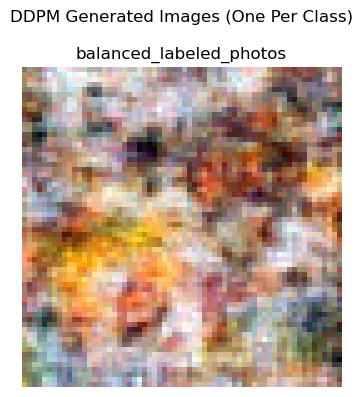

In [17]:
# Run after training
generate_per_class(model)

# LLM Prompts:
1. Provide step by step workflow to implement conditional DDPM model.
2. Write a code to extract dataset from zip file. 
3. Okay now i have extracted data so provide code without extracting data from zip as it started giving me an error.
4. Provide in step solution from scratch to perform conditional DDPM model including data preparation.
5. I have used normal pip, !pip to install libraries but it still gave me an error. provide alternative way to install it i'm using vscode to run ipynb file.

# Taran's Contribution

## Evaluation

### Install & Import TorchMetrics

In [18]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

### Evaluate FID and IS

In [19]:
@torch.no_grad()
def evaluate_fid_and_is(model, real_loader, label_for_gen=0, n_samples=128):
    model.eval()
    fake_imgs = sample_ddpm(model, n_samples=n_samples, label=label_for_gen)
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)

    real_batch, _ = next(iter(real_loader))
    real_uint8 = ((real_batch * 0.5 + 0.5) * 255).to(torch.uint8).to(fake_imgs.device)

    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    isc = InceptionScore(normalize=True).to(device)

    fid.update(real_uint8, real=True)
    fid.update(fake_uint8, real=False)
    isc.update(fake_uint8)

    return fid.compute().item(), isc.compute()[0].item()


In [20]:
fid_score, is_score = evaluate_fid_and_is(model, dataloader, label_for_gen=0)
print(f"FID: {fid_score:.2f}")
print(f"Inception Score: {is_score:.2f}")


/opt/anaconda3/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


FID: 523.83
Inception Score: 1.36


In [36]:
import torch.nn as nn
import torch.optim as optim

# Example classifier for your dataset (simple CNN)
class SimpleClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128), nn.ReLU(),  # for 32x32 input
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

classifier = SimpleClassifier(num_classes).to(device)

# Training loop (quick example)
criterion = nn.CrossEntropyLoss()
optimizer_cls = optim.Adam(classifier.parameters(), lr=1e-3)
epochs_cls = 10

for epoch in range(epochs_cls):
    classifier.train()
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = classifier(images)
        loss = criterion(outputs, labels)
        optimizer_cls.zero_grad()
        loss.backward()
        optimizer_cls.step()
    print(f"Classifier Epoch {epoch+1}/{epochs_cls} done.")

# Save weights
torch.save(classifier.state_dict(), "simple_classifier.pth")
print("Classifier weights saved to simple_classifier.pth")

Classifier Epoch 1/10 done.
Classifier Epoch 2/10 done.
Classifier Epoch 2/10 done.
Classifier Epoch 3/10 done.
Classifier Epoch 3/10 done.
Classifier Epoch 4/10 done.
Classifier Epoch 4/10 done.
Classifier Epoch 5/10 done.
Classifier Epoch 5/10 done.
Classifier Epoch 6/10 done.
Classifier Epoch 6/10 done.
Classifier Epoch 7/10 done.
Classifier Epoch 7/10 done.
Classifier Epoch 8/10 done.
Classifier Epoch 8/10 done.
Classifier Epoch 9/10 done.
Classifier Epoch 9/10 done.
Classifier Epoch 10/10 done.
Classifier weights saved to simple_classifier.pth
Classifier Epoch 10/10 done.
Classifier weights saved to simple_classifier.pth


### Confusion Matrix (Classifier-Based)

In [41]:
def resize_for_classifier(images):
    return torch.nn.functional.interpolate(images, size=(32, 32), mode='bilinear', align_corners=False)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


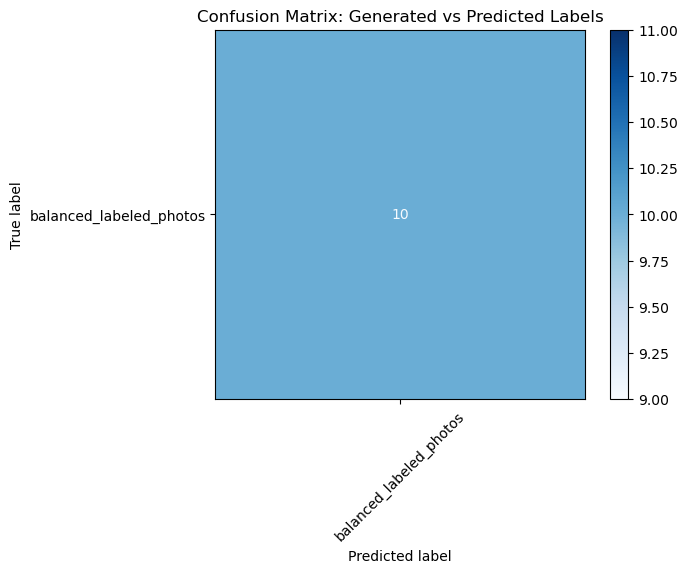

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch.nn.functional as F

def evaluate_confusion(model, classifier, T):
    y_true, y_pred = [], []

    for label in range(num_classes):
        imgs = sample_ddpm(model, 10, label=label, img_size=64)
        imgs_resized = resize_for_classifier(imgs)
        with torch.no_grad():
            logits = classifier(imgs_resized.to(device))
            preds = logits.argmax(1).cpu().tolist()
        y_true.extend([label]*len(preds))
        y_pred.extend(preds)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=full_dataset.classes)
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title("Confusion Matrix: Generated vs Predicted Labels")
    plt.show()

evaluate_confusion(model, classifier, T)


# LLM Prompts:
1. Here's my task to evaluate model so I want to perform model evaluation and find FID and Inception score.
2. Facing error while installing pip install 'torchmetrics[image]' scikit-learn pillow. provide correct solution to install it.
3. Evaluate model by ploting confusion matrix.

# Nithish's Contribution

### LIME for Interpretability

In [ ]:
%pip install lime

Using label index 0: balanced_labeled_photos


  0%|          | 0/1000 [00:00<?, ?it/s]

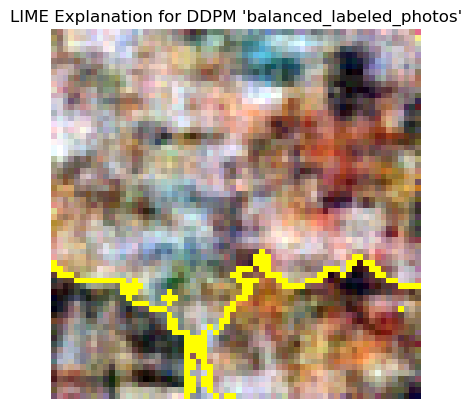

In [43]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np
import matplotlib.pyplot as plt

#  Define safe label
safe_label = min(2, num_classes - 1)  # ensures label is valid (e.g. 2 or below)
print(f"Using label index {safe_label}: {full_dataset.classes[safe_label]}")

#  Generate DDPM image for that label
img_tensor = sample_ddpm(model, 1, label=safe_label)[0]  # shape: [3, H, W]
img_np = (img_tensor.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

#  Create LIME explainer
explainer = lime_image.LimeImageExplainer()

#  Define classifier wrapper for LIME
def classifier_wrapper(images):
    images = torch.tensor(images).permute(0, 3, 1, 2).float() / 255.0
    images = resize_for_classifier(images)
    images = transforms.Normalize([0.5]*3, [0.5]*3)(images)
    outputs = classifier(images.to(device)).detach().cpu().numpy()
    return outputs

#  Run LIME on generated image
explanation = explainer.explain_instance(
    img_np,
    classifier_wrapper,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

#  Visualize explanation
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"LIME Explanation for DDPM '{full_dataset.classes[safe_label]}'")
plt.axis("off")
plt.show()


# LLM Prompts:
1. Do model interpretability for the DDPM model attached here.
2. What should i use for interpretability should i use LIME or Gradecam.